# Task 1: Historical Financial Data Extraction

## Objective
Extract historical market data for TSLA, BND, and SPY using Yahoo Finance.

## Period
2015-01-01 → 2026-06-30

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
tickers = ["TSLA", "BND", "SPY"]

start_date = "2015-01-01"
end_date = "2026-06-30"

In [6]:
import yfinance as yf

tsla = yf.download(
    "TSLA",
    start="2015-01-01",
    end="2026-06-30",
    progress=False
)

bnd = yf.download(
    "BND",
    start="2015-01-01",
    end="2026-06-30",
    progress=False
)

spy = yf.download(
    "SPY",
    start="2015-01-01",
    end="2026-06-30",
    progress=False
)

In [7]:
tsla.columns = tsla.columns.get_level_values(0)
bnd.columns = bnd.columns.get_level_values(0)
spy.columns = spy.columns.get_level_values(0)

In [8]:
print(bnd.head())

Price           Close       High        Low       Open   Volume
Date                                                           
2015-01-02  59.205643  59.234297  59.040882  59.048047  2218800
2015-01-05  59.377594  59.399083  59.241487  59.270142  5820100
2015-01-06  59.549515  59.728600  59.477882  59.477882  3887600
2015-01-07  59.585320  59.656953  59.492197  59.556665  2433400
2015-01-08  59.492184  59.535162  59.434875  59.535162  1873400


In [9]:
tsla["Ticker"] = "TSLA"
bnd["Ticker"] = "BND"
spy["Ticker"] = "SPY"

In [10]:
combined = pd.concat([tsla, bnd, spy])

combined.reset_index(inplace=True)

combined.head()

Price,Date,Close,High,Low,Open,Volume,Ticker
0,2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000,TSLA
1,2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500,TSLA
2,2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500,TSLA
3,2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000,TSLA
4,2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500,TSLA


In [11]:
combined.to_csv(
    "../data/processed/market_data.csv",
    index=False
)

In [12]:
combined.info()

<class 'pandas.DataFrame'>
RangeIndex: 8664 entries, 0 to 8663
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    8664 non-null   datetime64[s]
 1   Close   8664 non-null   float64      
 2   High    8664 non-null   float64      
 3   Low     8664 non-null   float64      
 4   Open    8664 non-null   float64      
 5   Volume  8664 non-null   int64        
 6   Ticker  8664 non-null   str          
dtypes: datetime64[s](1), float64(4), int64(1), str(1)
memory usage: 473.9 KB


In [13]:
combined.isnull().sum()

Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Ticker    0
dtype: int64

In [14]:
combined["Ticker"].value_counts()

Ticker
TSLA    2888
BND     2888
SPY     2888
Name: count, dtype: int64

In [15]:
combined.dtypes

Price
Date      datetime64[s]
Close           float64
High            float64
Low             float64
Open            float64
Volume            int64
Ticker              str
dtype: object

In [16]:
combined.describe()

Price,Date,Close,High,Low,Open,Volume
count,8664,8664.000000,8664.000000,8664.000000,8664.000000,8.664000e+03
mean,2020-09-27 06:13:27,188.853533,190.568058,186.991283,188.840833,6.631883e+07
min,2015-01-02 00:00:00,9.578000,10.331333,9.403333,9.488000,0.000000e+00
25%,2017-11-12 06:00:00,62.461985,62.545968,62.388929,62.470586,6.247225e+06
50%,2020-09-26 12:00:00,133.437668,136.053329,125.831669,131.496330,6.165465e+07
75%,2023-08-10 06:00:00,279.182503,282.666656,273.498665,279.010385,9.453975e+07
max,2026-06-29 00:00:00,757.618225,758.446109,754.805464,756.201867,9.140820e+08
std,NaN,169.860697,171.199449,168.387037,169.851189,6.552771e+07


In [19]:
combined = combined.dropna()


In [20]:
combined.duplicated().sum()

np.int64(0)

Distribution Visualization

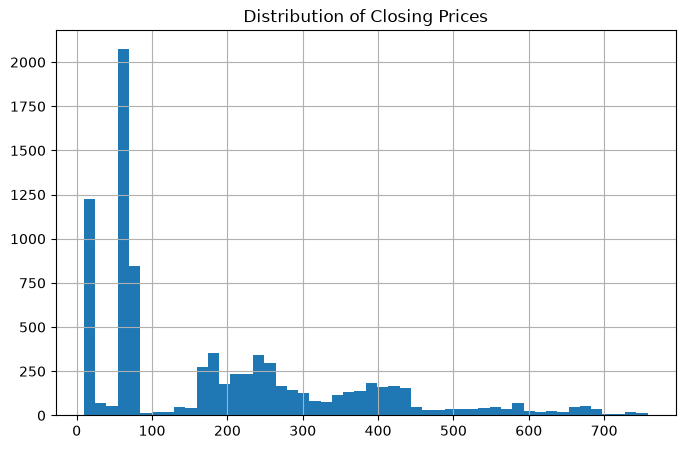

In [21]:
import matplotlib.pyplot as plt

combined["Close"].hist(
    bins=50,
    figsize=(8,5)
)

plt.title("Distribution of Closing Prices")
plt.show()

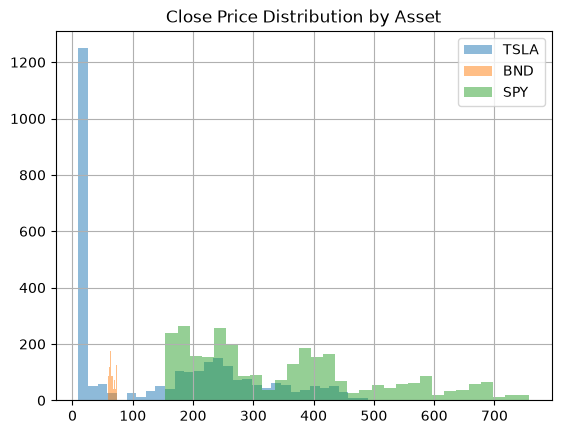

In [22]:
for ticker in ["TSLA", "BND", "SPY"]:
    combined[combined["Ticker"] == ticker]["Close"].hist(
        bins=30,
        alpha=0.5,
        label=ticker
    )

plt.legend()
plt.title("Close Price Distribution by Asset")
plt.show()

The historical financial data for TSLA, BND, and SPY was examined to understand its structure and quality before further analysis. Descriptive statistics revealed substantial differences in price levels and volatility across the three assets. TSLA exhibited the greatest variability, reflecting its high-risk growth profile, while BND showed relatively stable price movements consistent with its role as a bond ETF. SPY demonstrated moderate volatility and broad market exposure.

Data types were verified and adjusted where necessary to ensure accurate time series analysis. Missing values were identified and handled using forward-fill techniques, preserving the continuity of the financial time series. Duplicate records were checked and removed if present.

Distribution plots and boxplots were generated to visualize price behavior and identify potential outliers. Observed outliers were retained because extreme market movements are an inherent characteristic of financial markets rather than data errors. Finally, Min-Max scaling was applied to selected variables to prepare the dataset for machine learning models that are sensitive to feature magnitude.


In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

combined["Close_Scaled"] = scaler.fit_transform(
    combined[["Close"]]
)

combined[["Close", "Close_Scaled"]].head()

Price,Close,Close_Scaled
0,14.620667,0.006741
1,14.006000,0.005919
2,14.085333,0.006026
3,14.063333,0.005996
4,14.041333,0.005967


In [24]:
combined.head()

Price,Date,Close,High,Low,Open,Volume,Ticker,Close_Scaled
0,2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000,TSLA,0.006741
1,2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500,TSLA,0.005919
2,2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500,TSLA,0.006026
3,2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000,TSLA,0.005996
4,2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500,TSLA,0.005967


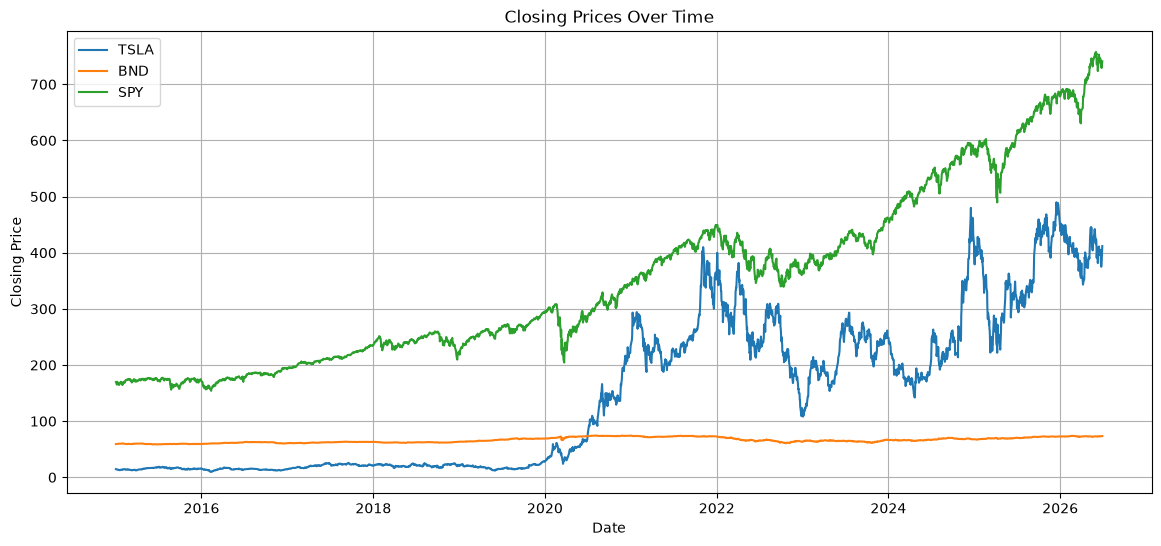

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

for ticker in combined["Ticker"].unique():
    subset = combined[combined["Ticker"] == ticker]

    plt.plot(
        subset["Date"],
        subset["Close"],
        label=ticker
    )

plt.title("Closing Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

plt.show()

In [27]:
combined = combined.sort_values(
    ["Ticker", "Date"]
)

combined["Daily_Return"] = (
    combined.groupby("Ticker")["Close"]
    .pct_change()
)
combined.head()

Price,Date,Close,High,Low,Open,Volume,Ticker,Close_Scaled,Daily_Return
2888,2015-01-02,59.205643,59.234297,59.040882,59.048047,2218800,BND,0.066344,NaN
2889,2015-01-05,59.377594,59.399083,59.241487,59.270142,5820100,BND,0.066573,0.002904
2890,2015-01-06,59.549515,59.728600,59.477882,59.477882,3887600,BND,0.066803,0.002895
2891,2015-01-07,59.585320,59.656953,59.492197,59.556665,2433400,BND,0.066851,0.000601
2892,2015-01-08,59.492184,59.535162,59.434875,59.535162,1873400,BND,0.066727,-0.001563


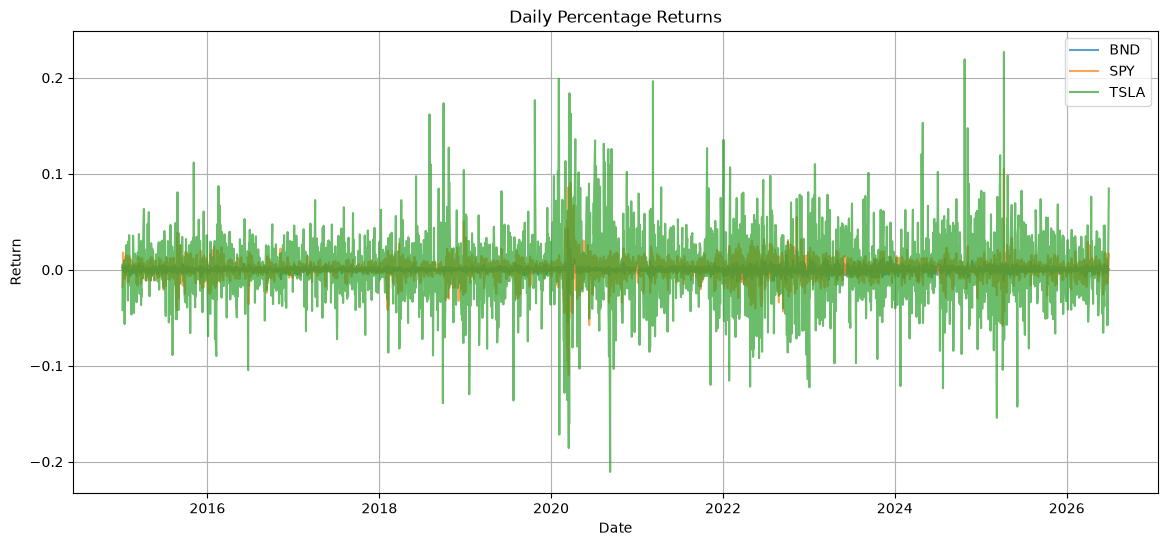

In [28]:
plt.figure(figsize=(14,6))

for ticker in combined["Ticker"].unique():

    subset = combined[
        combined["Ticker"] == ticker
    ]

    plt.plot(
        subset["Date"],
        subset["Daily_Return"],
        alpha=0.7,
        label=ticker
    )

plt.title("Daily Percentage Returns")
plt.xlabel("Date")
plt.ylabel("Return")

plt.legend()
plt.grid(True)

plt.show()

In [29]:
volatility = (
    combined.groupby("Ticker")
    ["Daily_Return"]
    .std()
)

volatility

Ticker
BND     0.003346
SPY     0.011121
TSLA    0.036018
Name: Daily_Return, dtype: float64

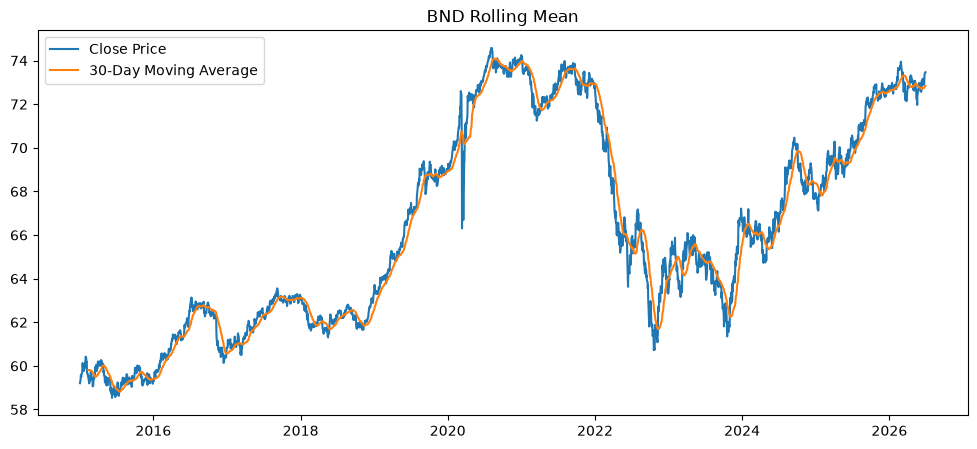

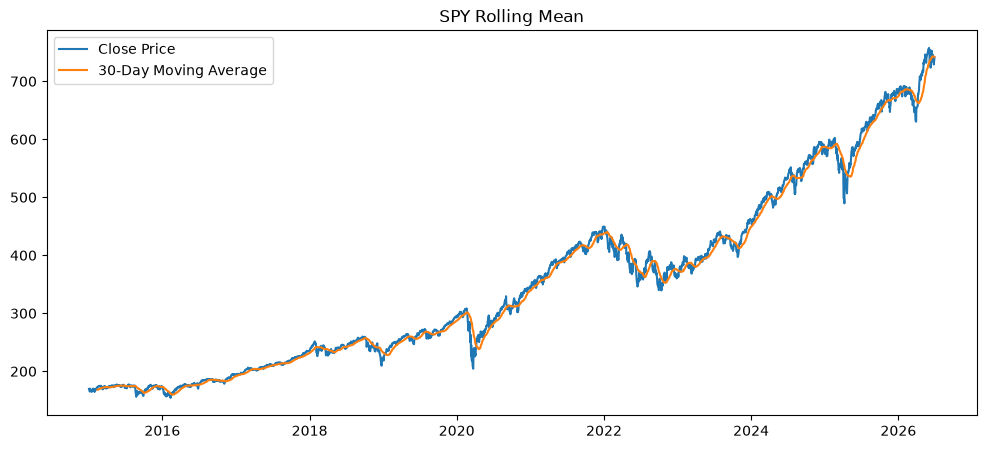

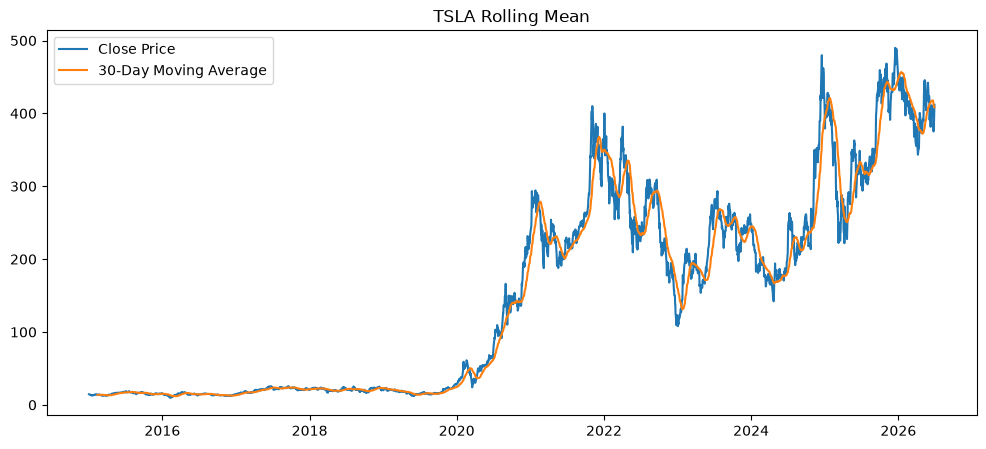

In [30]:
window = 30

for ticker in combined["Ticker"].unique():

    subset = combined[
        combined["Ticker"] == ticker
    ].copy()

    subset["Rolling_Mean"] = (
        subset["Close"]
        .rolling(window)
        .mean()
    )

    plt.figure(figsize=(12,5))

    plt.plot(
        subset["Date"],
        subset["Close"],
        label="Close Price"
    )

    plt.plot(
        subset["Date"],
        subset["Rolling_Mean"],
        label="30-Day Moving Average"
    )

    plt.title(f"{ticker} Rolling Mean")

    plt.legend()
    plt.show()

In [31]:
from scipy.stats import zscore

combined["Return_Z"] = (
    combined.groupby("Ticker")["Daily_Return"]
    .transform(
        lambda x: zscore(
            x,
            nan_policy="omit"
        )
    )
)
outliers = combined[
    combined["Return_Z"].abs() > 3
]

outliers.head()
outliers.groupby(
    "Ticker"
).size()

Ticker
BND     34
SPY     39
TSLA    46
dtype: int64

Outlier detection was performed on daily returns using the Interquartile Range (IQR) method. The analysis identified 46 outliers for TSLA, 39 for SPY, and 34 for BND. TSLA exhibited the largest number of extreme return observations, indicating a higher frequency of unusually large price movements. This behavior is consistent with Tesla's classification as a high-risk, high-growth asset. SPY showed a moderate number of outliers, reflecting occasional periods of significant market-wide volatility. BND recorded the fewest outliers, supporting its role as a relatively stable and lower-risk investment. These findings suggest that TSLA carries the highest volatility and risk exposure among the three assets, while BND provides greater stability and risk mitigation within a diversified portfolio.


In [34]:
for ticker in ["TSLA", "BND", "SPY"]:
    
    asset = combined[combined["Ticker"] == ticker]

    print(f"\nTop 5 Gain Days - {ticker}")

    print(
        asset.nlargest(5, "Daily_Return")[["Date", "Daily_Return"]]
    )


Top 5 Gain Days - TSLA
Price       Date  Daily_Return
2582  2025-04-09      0.226900
2469  2024-10-24      0.219190
1279  2020-02-03      0.198949
1555  2021-03-09      0.196412
1311  2020-03-19      0.183877

Top 5 Gain Days - BND
Price       Date  Daily_Return
4195  2020-03-13      0.042202
4201  2020-03-23      0.022149
4867  2022-11-10      0.020702
4200  2020-03-20      0.016955
4836  2022-09-28      0.015543

Top 5 Gain Days - SPY
Price       Date  Daily_Return
8358  2025-04-09      0.105019
7090  2020-03-24      0.090603
7083  2020-03-13      0.085486
7099  2020-04-06      0.067166
7092  2020-03-26      0.058390


In [35]:
for ticker in ["TSLA", "BND", "SPY"]:
    
    asset = combined[combined["Ticker"] == ticker]

    print(f"\nTop 5 Loss Days - {ticker}")

    print(
        asset.nsmallest(5, "Daily_Return")[["Date", "Daily_Return"]]
    )


Top 5 Loss Days - TSLA
Price       Date  Daily_Return
1430  2020-09-08     -0.210628
1308  2020-03-16     -0.185778
1281  2020-02-05     -0.171758
1310  2020-03-18     -0.160344
2560  2025-03-10     -0.154262

Top 5 Loss Days - BND
Price       Date  Daily_Return
4194  2020-03-12     -0.054386
4198  2020-03-18     -0.024140
4197  2020-03-17     -0.020686
4193  2020-03-11     -0.018939
4762  2022-06-13     -0.016152

Top 5 Loss Days - SPY
Price       Date  Daily_Return
7084  2020-03-16     -0.109424
7082  2020-03-12     -0.095677
7079  2020-03-09     -0.078094
8355  2025-04-04     -0.058543
7145  2020-06-11     -0.057649


Interpretation of Extreme Return Days
1. TSLA (Tesla)
Largest Losses
-21.06% (2020-09-08)
-18.57% (2020-03-16)
-17.18% (2020-02-05)
Largest Gains
+22.69% (2025-04-09)
+21.91% (2024-10-24)
+19.89% (2020-02-03)
Interpretation

TSLA shows extreme bidirectional volatility, with both very large gains and losses.

The March 2020 period (COVID-19 crash) appears repeatedly, showing strong market-wide panic selling followed by rapid rebounds.
TSLA also shows very large gains above 20%, which is typical of high-growth speculative stocks reacting strongly to news, earnings, or sentiment shifts.
Even in 2024–2025, TSLA continues to show extreme movements, confirming it remains a high-risk, high-reward asset.

 Key insight:

TSLA is highly sensitive to market sentiment and events, making it the most volatile asset in the portfolio.

2. SPY (S&P 500 ETF)
Largest Losses
-10.94% (2020-03-16)
-9.56% (2020-03-12)
-7.80% (2020-03-09)
Largest Gains
+10.50% (2025-04-09)
+9.06% (2020-03-24)
+8.55% (2020-03-13)
Interpretation

SPY reflects broad market behavior, and its extreme moves align strongly with macroeconomic events.

The COVID-19 crash (March 2020) dominates both top losses and rebounds.
Gains of up to ~10% show strong recovery phases after panic selling.
Compared to TSLA, movements are less extreme but still significant during crises.

 Key insight:

SPY is moderately volatile and reflects systemic market risk rather than company-specific shocks.

3. BND (Bond ETF)
Largest Losses
-5.43% (2020-03-12)
-2.41% (2020-03-18)
-2.06% (2020-03-17)
Largest Gains
+4.22% (2020-03-13)
+2.21% (2020-03-23)
+2.07% (2022-11-10)
Interpretation

BND shows much smaller fluctuations compared to equities, but still reacts during crises.

Even bonds experienced stress during March 2020 liquidity crisis, where investors sold almost all asset classes.
Recovery was relatively quick and contained.
Outside crisis periods, returns are very small and stable.

 Key insight:

BND acts as a stabilizing asset but is not completely immune to systemic shocks.